# EDA — Détection glaucome référable (RG)

Exploration du sous-ensemble ML : **dossier 0 uniquement** (18k images).  
Labels : NRG (non référable) / RG (référable).

In [1]:
import sys
from pathlib import Path
# Fonctionne dans Cursor/VS Code (cwd = glaucome) ou Jupyter (cwd = notebooks/)
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "train_labels.csv").exists() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loading import get_ml_subset_df, get_train_val_test_splits

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Chargement du sous-ensemble (dossier 0)

In [2]:
df = get_ml_subset_df()
print("Shape:", df.shape)
df.head()

Shape: (18000, 3)


,challenge_id,class,path
0,TRAIN000000,NRG,0/TRAIN000000.jpg
1,TRAIN000001,NRG,0/TRAIN000001.jpg
2,TRAIN000002,NRG,0/TRAIN000002.jpg
3,TRAIN000003,NRG,0/TRAIN000003.jpg
4,TRAIN000004,NRG,0/TRAIN000004.jpg


## 2. Répartition des classes

In [3]:
counts = df["class"].value_counts()
print(counts)
print("\nProportions:")
print(df["class"].value_counts(normalize=True).round(4))

class
NRG    17398
RG       602
Name: count, dtype: int64

Proportions:
class
NRG    0.9666
RG     0.0334
Name: proportion, dtype: float64


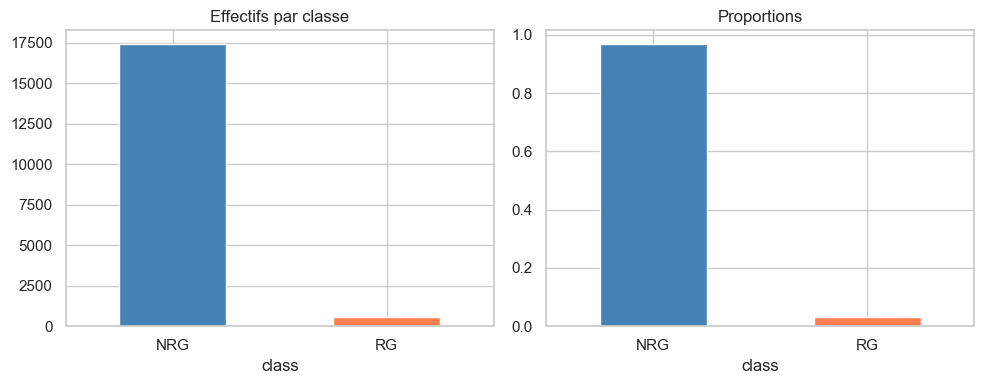

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts.plot(kind="bar", ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("Effectifs par classe")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
df["class"].value_counts(normalize=True).plot(kind="bar", ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("Proportions")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 3. Qualité / taille des images

In [ ]:
from PIL import Image

sizes = []
for path in df["path"].head(500):  # échantillon
    p = PROJECT_ROOT / path
    try:
        with Image.open(p) as im:
            sizes.append(im.size)
    except Exception:
        pass
if sizes:
    w, h = zip(*sizes)
    print("Échantillon 500 images — largeur:", min(w), "-", max(w), ", hauteur:", min(h), "-", max(h))

Échantillon 500 images — largeur: 1634 - 6000 , hauteur: 1630 - 4000


## 4. Exemples visuels par classe

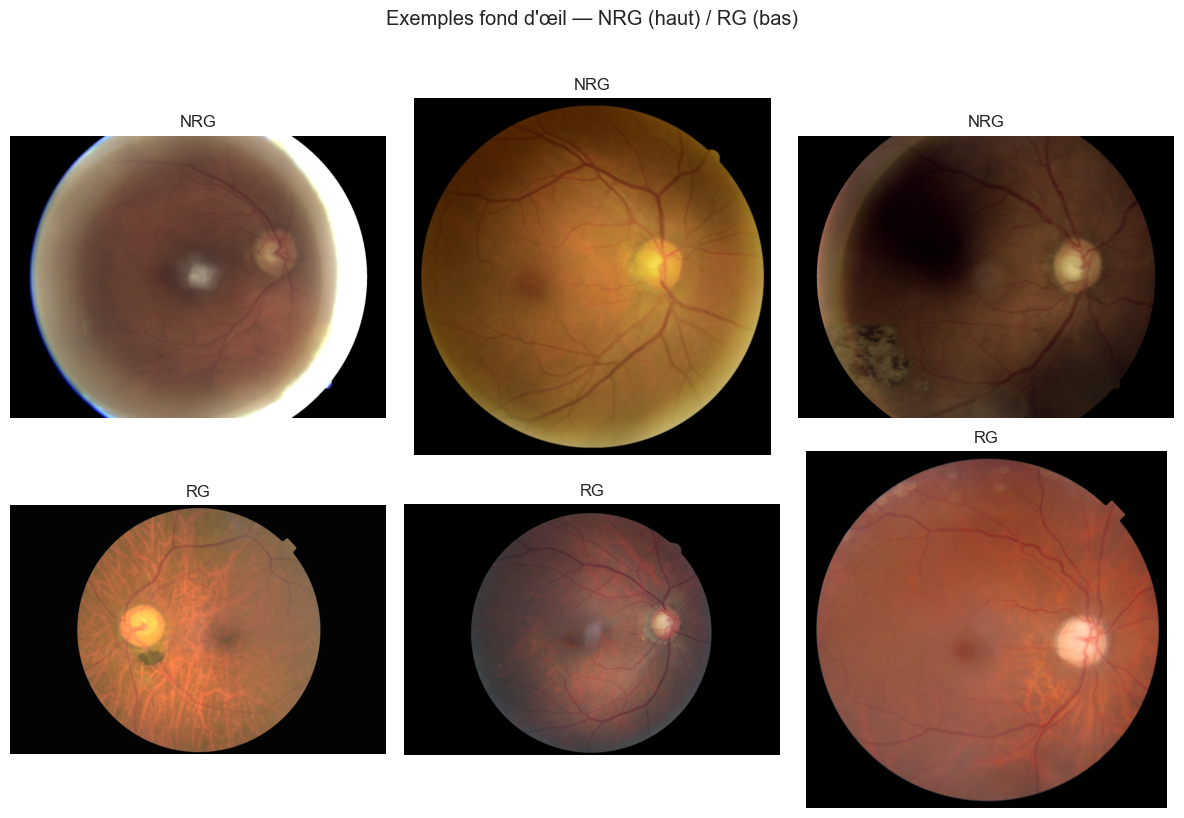

In [6]:
n_per_class = 3
fig, axes = plt.subplots(2, n_per_class, figsize=(4 * n_per_class, 8))
for i, cls in enumerate(["NRG", "RG"]):
    sub = df[df["class"] == cls].sample(n=n_per_class, random_state=42)
    for j, (_, row) in enumerate(sub.iterrows()):
        path = PROJECT_ROOT / row["path"]
        if path.exists():
            img = plt.imread(path)
            axes[i, j].imshow(img)
        axes[i, j].set_title(f"{cls}")
        axes[i, j].axis("off")
plt.suptitle("Exemples fond d\'œil — NRG (haut) / RG (bas)", y=1.02)
plt.tight_layout()
plt.show()

## 5. Découpage train / validation / test

In [7]:
train_df, val_df, test_df = get_train_val_test_splits(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15)
print("Train:", len(train_df), "— Val:", len(val_df), "— Test:", len(test_df))
print("\nRépartition RG dans train:", train_df["class"].value_counts(normalize=True).round(4).to_dict())

Train: 12600 — Val: 2700 — Test: 2700

Répartition RG dans train: {'NRG': 0.9665, 'RG': 0.0335}
